**Purpose:** Mean-variance optimization benchmark with CAPM expected returns.

**Outputs:** `MVO_CAPM_weights.npy`

**Notes:** paths resolve via `src.config` (run `pip install -e .` from the repo root first).


In [ ]:
from src.config import PROJECT_ROOT
from src.seeds import SEED_PORTFOLIO_BENCHMARKS_MVO_CAPM_V3_2_0


# CAPM Max-Sharpe Portfolio — Clean Walk-Forward + Optuna

This notebook:
- loads and aligns data
- runs a clean walk-forward CAPM max-Sharpe backtest
- tunes hyperparameters with Optuna on the validation period
- fixes best params and evaluates on test
- outputs daily test weights and test Sharpe


- Optuna tends to overfit if many trials, ence the creation of "estimate_search_space()": based on the #discrete and #categorical hyperparameters. Does the sqrt of the possibilities. Doesn't take into account the continuous hyperparameters.

In [2]:
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import optuna
import yfinance as yf
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


## 1) Config

In [3]:
# -------------------------
# PATHS
# -------------------------
DATASET_PATH = Path(str(PROJECT_ROOT / '03_portfolio/dataset.parquet'))
RF_PATH = Path(str(PROJECT_ROOT / '01_data/aux/1M_TBills_full_history.csv'))
SPREADS_PATH = Path(str(PROJECT_ROOT / '01_data/aux/bid-ask_spread.json'))

# -------------------------
# UNIVERSE
# -------------------------
ASSETS = ['XLB', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY']
MARKET_TICKER = '^GSPC'

# -------------------------
# DATE SPLITS
# -------------------------
# Walk-forward CV folds: (train_start, train_end, val_start, val_end)
CV_PERIODS = [
    (pd.Timestamp('2015-07-01'), pd.Timestamp('2020-06-30'),
     pd.Timestamp('2020-07-01'), pd.Timestamp('2021-06-30')),
    (pd.Timestamp('2015-07-01'), pd.Timestamp('2021-06-30'),
     pd.Timestamp('2021-07-01'), pd.Timestamp('2022-06-30')),
    (pd.Timestamp('2015-07-01'), pd.Timestamp('2022-06-30'),
     pd.Timestamp('2022-07-01'), pd.Timestamp('2023-06-30')),
]
# Final test window (after all val folds)
TEST_START = pd.Timestamp('2023-07-01')

# -------------------------
# OPTUNA / SEARCH SPACE
# -------------------------
LOOKBACK_MAP = {
    '5d': 5,
    '22d': 22,
    '3m': 63,
    '6m': 126,
    '1y': 252,
    '2y': 504,
    '3y': 756,
}

REBALANCE_CHOICES = ['daily', 'weekly', 'biweekly', 'monthly', 'quarterly']

# -------------------------
# STUDY STORAGE
# -------------------------
STUDY_NAME = 'capm_max_sharpe_validation_net_sharpe'
STORAGE = 'sqlite:///v320.db'
SEED = SEED_PORTFOLIO_BENCHMARKS_MVO_CAPM_V3_2_0
import json
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.optimize import minimize
import sys
from pathlib import Path
from src.metrics import PortfolioMetrics


## 2) Data loading and alignment

In [4]:
def load_data(dataset_path: Path, rf_path: Path, spreads_path: Path, assets: list[str], market_ticker: str):
    df = pd.read_parquet(dataset_path, engine="pyarrow").copy()

    close_cols = [f'{a}_Close' for a in assets]
    missing_close_cols = [c for c in close_cols if c not in df.columns]
    if missing_close_cols:
        raise ValueError(f'Missing close columns in dataset: {missing_close_cols}')

    asset_prices = df[close_cols].copy()
    asset_prices.columns = assets
    asset_returns = asset_prices.pct_change()

    # market_prices = yf.download(market_ticker, start=asset_prices.index.min(), end=asset_prices.index.max() + pd.Timedelta(days=1), progress=False)['Close']
    # market_returns = market_prices.pct_change().rename(market_ticker)
    market_returns = (yf.download("^GSPC", start="2015-07-01", end="2025-07-01")["Close"]
                  .pct_change()
                  .reindex(asset_returns.index)
                  .dropna())
    

    rf = (
        pd.read_csv(rf_path)
        .set_index('observation_date')
        .rename_axis(None)
        .pipe(lambda x: x.set_index(pd.to_datetime(x.index)))
        .iloc[:, 0]
        .astype(float)
        .div(100)
        .div(252)
        .rename('rf')
    )

    with open(spreads_path, 'r') as f:
        spreads = json.load(f)

    missing_spreads = [a for a in assets if a not in spreads]
    if missing_spreads:
        raise ValueError(f'Missing spreads for assets: {missing_spreads}')

    common_index = asset_returns.index.intersection(market_returns.index).intersection(rf.index)
    common_index = common_index.sort_values()

    asset_returns = asset_returns.reindex(common_index)
    market_returns = market_returns.reindex(common_index)
    rf = rf.reindex(common_index).ffill()

    # Drop leading rows where market/rf are still missing or all assets are missing.
    valid_mask = market_returns.notna() & rf.notna()
    valid_mask &= asset_returns.notna().any(axis=1)
    first_valid = valid_mask[valid_mask].index.min()

    asset_returns = asset_returns.loc[first_valid:].copy()
    market_returns = market_returns.loc[first_valid:].copy()
    rf = rf.loc[first_valid:].copy()

    return asset_returns, market_returns, rf, spreads


In [5]:
returns, market_returns, rf, spreads = load_data(
    dataset_path=DATASET_PATH,
    rf_path=RF_PATH,
    spreads_path=SPREADS_PATH,
    assets=ASSETS,
    market_ticker=MARKET_TICKER,
)

print('returns shape      :', returns.shape)
print('market_returns len :', len(market_returns))
print('rf len             :', len(rf))
print('date range         :', returns.index.min().date(), '->', returns.index.max().date())
display(returns.head())


[*********************100%***********************]  1 of 1 completed


returns shape      : (2513, 11)
market_returns len : 2513
rf len             : 2513
date range         : 2015-07-02 -> 2025-06-30


,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
2015-07-02,-0.003082,NaN,0.004448,-0.004445,-0.001841,0.001439,-0.000830,NaN,0.012467,-0.004655,-0.001939
2015-07-06,-0.008245,NaN,-0.013149,-0.004058,-0.003872,-0.004073,-0.000830,NaN,0.004026,-0.000401,-0.001943
2015-07-07,-0.003326,NaN,0.009109,0.002037,0.008145,0.001443,0.020569,NaN,0.024764,0.004812,0.008696
2015-07-08,-0.021898,NaN,-0.020210,-0.017487,-0.017995,-0.016334,-0.011197,NaN,-0.005293,-0.017161,-0.019043
2015-07-09,0.002985,NaN,0.005088,0.007865,0.002431,-0.003907,0.000823,NaN,-0.011106,0.005414,0.004197


## 3) Backtest helpers

In [6]:
def annualized_sharpe(returns_net: pd.Series, rf_daily: pd.Series | None = None, periods_per_year: int = 252) -> float:
    returns_net = returns_net.dropna().copy()
    if returns_net.empty:
        return np.nan

    if rf_daily is not None:
        aligned_rf = rf_daily.reindex(returns_net.index).ffill()
        excess = returns_net - aligned_rf
    else:
        excess = returns_net

    vol = excess.std(ddof=1)
    if pd.isna(vol) or vol <= 0:
        return np.nan

    return np.sqrt(periods_per_year) * excess.mean() / vol


def get_rebalance_dates(index: pd.DatetimeIndex, freq: str) -> pd.DatetimeIndex:
    idx = pd.DatetimeIndex(index).sort_values()

    if freq == 'daily':
        return idx

    if freq == 'weekly':
        schedule = idx.to_series().resample('W-MON').first().dropna().values
        return pd.DatetimeIndex(schedule)

    if freq == 'biweekly':
        weekly = idx.to_series().resample('W-MON').first().dropna()
        return pd.DatetimeIndex(weekly.iloc[::2].values)

    if freq == 'monthly':
        schedule = idx.to_series().resample('MS').first().dropna().values
        return pd.DatetimeIndex(schedule)

    if freq == 'quarterly':
        schedule = idx.to_series().resample('QS').first().dropna().values
        return pd.DatetimeIndex(schedule)

    raise ValueError(f'Unsupported rebalance frequency: {freq}')


def compute_capm_inputs(
    window_asset_returns: pd.DataFrame,
    window_market_returns: pd.Series,
    window_rf: pd.Series,
    rf_t: float,
    ridge: float,
):

    # --- ensure market returns is a Series ---
    if isinstance(window_market_returns, pd.DataFrame):
        window_market_returns = window_market_returns.iloc[:, 0]

    window_market_returns = window_market_returns.rename("market")

    aligned = window_asset_returns.join(window_market_returns, how="inner")

    eligible = aligned.drop(columns="market").dropna(axis=1, how="any")

    if eligible.shape[1] < 2:
        return None

    common_idx = eligible.index.intersection(window_market_returns.index).intersection(window_rf.index)

    eligible = eligible.loc[common_idx]
    market = window_market_returns.loc[common_idx]
    rf_aligned = window_rf.loc[common_idx]

    if len(common_idx) < 2:
        return None

    # covariance
    Sigma = eligible.cov().values
    Sigma += np.eye(Sigma.shape[0]) * ridge

    # betas
    market_var = market.var(ddof=1)

    if market_var <= 0 or np.isnan(market_var):
        return None

    cov_with_market = eligible.apply(lambda x: np.cov(x, market, ddof=1)[0, 1])
    betas = cov_with_market / market_var

    # CAPM expected return
    market_premium = market.mean() - rf_aligned.mean()
    mu = rf_t + betas * market_premium

    return {
        "assets": eligible.columns.tolist(),
        "Sigma": Sigma,
        "mu": mu.values.astype(float),
    }


def solve_max_sharpe(mu: np.ndarray, Sigma: np.ndarray, rf_t: float, method: str = 'SLSQP') -> tuple[np.ndarray, bool, str]:
    n = len(mu)
    w0 = np.full(n, 1.0 / n)
    bounds = [(0.0, 1.0)] * n
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]

    def neg_sharpe(w):
        port_ret = float(w @ mu)
        port_var = float(w @ Sigma @ w)
        if port_var <= 0:
            return 1e9
        port_vol = np.sqrt(port_var)
        return -((port_ret - rf_t) / port_vol)

    res = minimize(
        neg_sharpe,
        x0=w0,
        method=method,
        bounds=bounds,
        constraints=constraints,
    )

    if not res.success or np.any(~np.isfinite(res.x)):
        return w0, True, res.message

    w = np.clip(res.x, 0.0, 1.0)
    w = w / w.sum()
    return w, False, res.message


def transaction_cost_half_spread(
    new_weights: pd.Series,
    prev_weights: pd.Series | None,
    spreads: dict,
) -> float:
    if prev_weights is None:
        prev_aligned = pd.Series(0.0, index=new_weights.index)
    else:
        all_assets = new_weights.index.union(prev_weights.index)
        prev_aligned = prev_weights.reindex(all_assets).fillna(0.0)
        new_weights = new_weights.reindex(all_assets).fillna(0.0)

    traded_weight = (new_weights - prev_aligned).abs()
    half_spreads = pd.Series({a: spreads[a] / 2.0 for a in traded_weight.index}, index=traded_weight.index)
    return float((traded_weight * half_spreads).sum())


## 4) Walk-forward backtest engine

In [7]:
def run_walkforward_backtest(
    returns: pd.DataFrame,
    market_returns: pd.Series,
    rf: pd.Series,
    spreads: dict,
    lookback_days: int,
    rebalance_freq: str,
    ridge: float,
    start_date: str | pd.Timestamp,
    end_date: str | pd.Timestamp,
    optimizer_method: str = 'SLSQP',
    fallback_to_equal_weight: bool = True,
):
    start_date = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)

    all_index = returns.index
    rebalance_dates_all = get_rebalance_dates(all_index, rebalance_freq)
    rebalance_dates = rebalance_dates_all[(rebalance_dates_all >= start_date) & (rebalance_dates_all <= end_date)]

    if len(rebalance_dates) == 0:
        raise ValueError('No rebalance dates inside requested backtest range.')

    portfolio_returns_parts = []
    weight_records = {}
    prev_weights = None
    fallback_count = 0

    for i, t in enumerate(rebalance_dates):
        if t not in returns.index or t not in market_returns.index or t not in rf.index:
            continue

        end_loc = returns.index.get_loc(t)
        start_loc = end_loc - lookback_days
        if start_loc < 0:
            continue

        window_asset_returns = returns.iloc[start_loc:end_loc]
        window_market_returns = market_returns.iloc[start_loc:end_loc]
        window_rf = rf.iloc[start_loc:end_loc]
        rf_t = float(rf.loc[t])

        capm_inputs = compute_capm_inputs(
            window_asset_returns=window_asset_returns,
            window_market_returns=window_market_returns,
            window_rf=window_rf,
            rf_t=rf_t,
            ridge=ridge,
        )

        if capm_inputs is None:
            continue

        eligible_assets = capm_inputs['assets']
        mu = capm_inputs['mu']
        Sigma = capm_inputs['Sigma']

        w, did_fallback, _msg = solve_max_sharpe(mu=mu, Sigma=Sigma, rf_t=rf_t, method=optimizer_method)

        if did_fallback and not fallback_to_equal_weight:
            continue

        if did_fallback:
            fallback_count += 1

        current_weights = pd.Series(w, index=eligible_assets, dtype=float)
        weight_records[t] = current_weights

        cost = transaction_cost_half_spread(
            new_weights=current_weights,
            prev_weights=prev_weights,
            spreads=spreads,
        )

        if i + 1 < len(rebalance_dates):
            t_next = rebalance_dates[i + 1]
            period_asset_returns = returns.loc[t:t_next, eligible_assets].iloc[1:]
        else:
            period_asset_returns = returns.loc[t:end_date, eligible_assets].iloc[1:]

        if period_asset_returns.empty:
            prev_weights = current_weights
            continue

        port_ret = period_asset_returns @ current_weights
        port_ret = port_ret.astype(float)
        port_ret.iloc[0] -= cost

        portfolio_returns_parts.append(port_ret)
        prev_weights = current_weights

    if len(portfolio_returns_parts) == 0:
        raise ValueError('Backtest produced no portfolio returns. Usually means insufficient history for the requested lookback.')

    portfolio_returns = pd.concat(portfolio_returns_parts).sort_index()
    portfolio_returns = portfolio_returns[~portfolio_returns.index.duplicated(keep='first')]
    portfolio_returns = portfolio_returns.loc[(portfolio_returns.index >= start_date) & (portfolio_returns.index <= end_date)]

    weights_rebalance = pd.DataFrame(weight_records).T.sort_index() if weight_records else pd.DataFrame()

    if not weights_rebalance.empty:
        weight_index = returns.loc[start_date:end_date].index
        weights_daily = weights_rebalance.reindex(weight_index, method='ffill').fillna(0.0)
        row_sums = weights_daily.sum(axis=1)
        nonzero = row_sums > 0
        weights_daily.loc[nonzero] = weights_daily.loc[nonzero].div(row_sums[nonzero], axis=0)
    else:
        weights_daily = pd.DataFrame(index=returns.loc[start_date:end_date].index)

    sharpe = annualized_sharpe(portfolio_returns, rf_daily=rf)

    return {
        'portfolio_returns': portfolio_returns,
        'weights_rebalance': weights_rebalance,
        'weights_daily': weights_daily,
        'sharpe': sharpe,
        'fallback_count': fallback_count,
    }


## 5) Quick sanity check

In [8]:
sanity_result = run_walkforward_backtest(
    returns=returns,
    market_returns=market_returns,
    rf=rf,
    spreads=spreads,
    lookback_days=252,
    rebalance_freq='monthly',
    ridge=1e-6,
    start_date=CV_PERIODS[-1][2],
    end_date=CV_PERIODS[-1][3],
)

print('Sanity Sharpe (last val fold):', sanity_result['sharpe'])
print('Fallback count          :', sanity_result['fallback_count'])
display(sanity_result['weights_rebalance'].tail())


Sanity Sharpe (last val fold): 0.7663766095203899
Fallback count          : 0


,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
2023-02-01,0.000000e+00,8.313305e-16,1.000000,1.542800e-15,1.036289e-15,6.606285e-16,0.000000e+00,0.000000e+00,0.000000e+00,5.040439e-16,9.717535e-16
2023-03-01,0.000000e+00,4.272396e-16,1.000000,6.358800e-16,1.421849e-16,3.432464e-16,0.000000e+00,0.000000e+00,0.000000e+00,1.539424e-16,4.982798e-16
2023-04-03,1.296745e-16,0.000000e+00,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.231629e-16,6.307863e-16,1.804112e-15,0.000000e+00,0.000000e+00
2023-05-01,9.090909e-02,9.090909e-02,0.090909,9.090909e-02,9.090909e-02,9.090909e-02,9.090909e-02,9.090909e-02,9.090909e-02,9.090909e-02,9.090909e-02
2023-06-01,9.090909e-02,9.090909e-02,0.090909,9.090909e-02,9.090909e-02,9.090909e-02,9.090909e-02,9.090909e-02,9.090909e-02,9.090909e-02,9.090909e-02


## 6) Optuna objective

In [9]:
def make_objective(
    returns: pd.DataFrame,
    market_returns: pd.Series,
    rf: pd.Series,
    spreads: dict,
    cv_periods: list,
):
    """
    Optuna objective that averages the net Sharpe across all walk-forward
    CV folds. Each fold is defined by (train_start, train_end, val_start,
    val_end); only the val window is actually passed to run_walkforward_backtest
    (the full history up to val_end is available via `returns`, so the engine
    naturally uses the right lookback data from the beginning of `returns`).
    """
    def objective(trial: optuna.trial.Trial) -> float:
        lookback_label = trial.suggest_categorical('lookback_label', list(LOOKBACK_MAP.keys()))
        lookback_days  = LOOKBACK_MAP[lookback_label]
        rebalance_freq = trial.suggest_categorical('rebalance_freq', REBALANCE_CHOICES)
        ridge          = trial.suggest_float('cov_ridge', 1e-8, 1e-1, log=True)

        sharpes = []
        for _train_start, _train_end, val_start, val_end in cv_periods:
            try:
                result = run_walkforward_backtest(
                    returns=returns,
                    market_returns=market_returns,
                    rf=rf,
                    spreads=spreads,
                    lookback_days=lookback_days,
                    rebalance_freq=rebalance_freq,
                    ridge=ridge,
                    start_date=val_start,
                    end_date=val_end,
                    optimizer_method='SLSQP',
                    fallback_to_equal_weight=True,
                )
                s = result['sharpe']
                if pd.isna(s) or not np.isfinite(s):
                    s = -1e9
                sharpes.append(float(s))
            except Exception as e:
                trial.set_user_attr(f'error_{val_start.date()}', str(e))
                sharpes.append(-1e9)

        mean_sharpe = float(np.mean(sharpes))

        # store per-fold sharpes for inspection
        for (_, _, vs, ve), s in zip(cv_periods, sharpes):
            trial.set_user_attr(f'sharpe_{vs.date()}_{ve.date()}', s)

        return mean_sharpe

    return objective


## 7) Run / resume Optuna study

In [10]:
def estimate_search_space(study):
    """
    Inspects the study's distributions after at least 1 trial and prints:
      - discrete combinations (categorical × int params)
      - continuous params (float — excluded from count, infinite space)
      - suggested N_TRIALS ceiling  →  sqrt(discrete_combos)

    Nothing is applied automatically — use the suggestion as a ceiling
    when setting N_TRIALS.
    """
    if not study.trials:
        raise ValueError("Run at least 1 trial first so distributions are populated.")

    distributions = study.trials[0].distributions
    discrete_combinations = 1
    continuous_params = []

    for name, dist in distributions.items():
        if isinstance(dist, optuna.distributions.CategoricalDistribution):
            n = len(dist.choices)
            discrete_combinations *= n
            print(f"  {name:20s}  categorical   {n} choices: {list(dist.choices)}")
        elif isinstance(dist, optuna.distributions.IntDistribution):
            n = (dist.high - dist.low) // dist.step + 1
            discrete_combinations *= n
            print(f"  {name:20s}  int           {n} levels  [{dist.low} .. {dist.high}]")
        elif isinstance(dist, optuna.distributions.FloatDistribution):
            continuous_params.append(name)
            scale = 'log-scale' if dist.log else 'linear'
            print(f"  {name:20s}  float ({scale})  [{dist.low:.2e} .. {dist.high:.2e}]  ← continuous, excluded")

    suggested = math.ceil(math.sqrt(discrete_combinations))

    print()
    print(f"Discrete combinations : {discrete_combinations}")
    print(f"Continuous params     : {continuous_params}")
    print(f"Suggested N_TRIALS    : ceil(sqrt({discrete_combinations})) = {suggested}")
    print(f"  └─ treat this as a ceiling; more trials risk overfitting the val folds")
    return suggested


In [11]:
def run_optuna_study(n_trials: int):
    sampler = optuna.samplers.TPESampler(seed=SEED)

    study = optuna.create_study(
        study_name=STUDY_NAME,
        storage=STORAGE,
        direction='maximize',
        load_if_exists=True,
        sampler=sampler,
    )

    objective = make_objective(
        returns=returns,
        market_returns=market_returns,
        rf=rf,
        spreads=spreads,
        cv_periods=CV_PERIODS,
    )

    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study


In [12]:
# Choose the number of trials here.
N_TRIALS = 0

study = run_optuna_study(n_trials=N_TRIALS)

estimate_search_space(study)
print("You already tested: ", len(study.trials))


[I 2026-03-22 14:31:47,635] Using an existing study with name 'capm_max_sharpe_validation_net_sharpe' instead of creating a new one.


  lookback_label        categorical   7 choices: ['5d', '22d', '3m', '6m', '1y', '2y', '3y']
  rebalance_freq        categorical   5 choices: ['daily', 'weekly', 'biweekly', 'monthly', 'quarterly']
  cov_ridge             float (log-scale)  [1.00e-08 .. 1.00e-01]  ← continuous, excluded

Discrete combinations : 35
Continuous params     : ['cov_ridge']
Suggested N_TRIALS    : ceil(sqrt(35)) = 6
  └─ treat this as a ceiling; more trials risk overfitting the val folds
You already tested:  6


## 8) Inspect study results

In [13]:
trials_df = study.trials_dataframe(attrs=('number', 'value', 'params', 'user_attrs', 'state'))
trials_df = trials_df.sort_values('value', ascending=False)
display(trials_df.head(5))


,number,value,params_cov_ridge,params_lookback_label,params_rebalance_freq,user_attrs_sharpe_2020-07-01_2021-06-30,user_attrs_sharpe_2021-07-01_2022-06-30,user_attrs_sharpe_2022-07-01_2023-06-30,state
5,5,1.024209,9.042058e-06,22d,weekly,1.173316,0.866284,1.033028,COMPLETE
2,2,0.882105,1.035938e-08,3y,monthly,2.401529,-0.546202,0.790988,COMPLETE
3,3,0.882044,1.112951e-07,3y,monthly,2.401575,-0.546312,0.790870,COMPLETE
1,1,0.878972,2.196642e-04,3y,daily,2.396625,-0.458375,0.698664,COMPLETE
0,0,0.868528,4.570097e-07,1y,weekly,2.418279,-0.654774,0.842078,COMPLETE


## 9) Refit-free final test run with best validation hyperparameters

In [14]:
best_params = study.best_params.copy()
best_lookback_days = LOOKBACK_MAP[best_params['lookback_label']]
best_rebalance_freq = best_params['rebalance_freq']
best_ridge = best_params['cov_ridge']

test_result = run_walkforward_backtest(
    returns=returns,
    market_returns=market_returns,
    rf=rf,
    spreads=spreads,
    lookback_days=best_lookback_days,
    rebalance_freq=best_rebalance_freq,
    ridge=best_ridge,
    start_date=TEST_START,
    end_date=returns.index.max(),
    optimizer_method='SLSQP',
    fallback_to_equal_weight=True,
)

print('Best params              :', best_params)
print('Mean CV net Sharpe      :', study.best_value)
print('Test net Sharpe          :', test_result['sharpe'])
print('Test fallback count      :', test_result['fallback_count'])


Best params              : {'lookback_label': '22d', 'rebalance_freq': 'weekly', 'cov_ridge': 9.042057670319774e-06}
Mean CV net Sharpe      : 1.0242093677249662
Test net Sharpe          : 0.64276039961094
Test fallback count      : 0


## 10) Final outputs

{'cumulative_return': np.float64(0.37967758662367523), 'volatility': np.float64(0.146056537793912), 'sharpe_ratio': np.float64(0.8346601350767167), 'max_drawdown': np.float64(-0.18785482134329196)}


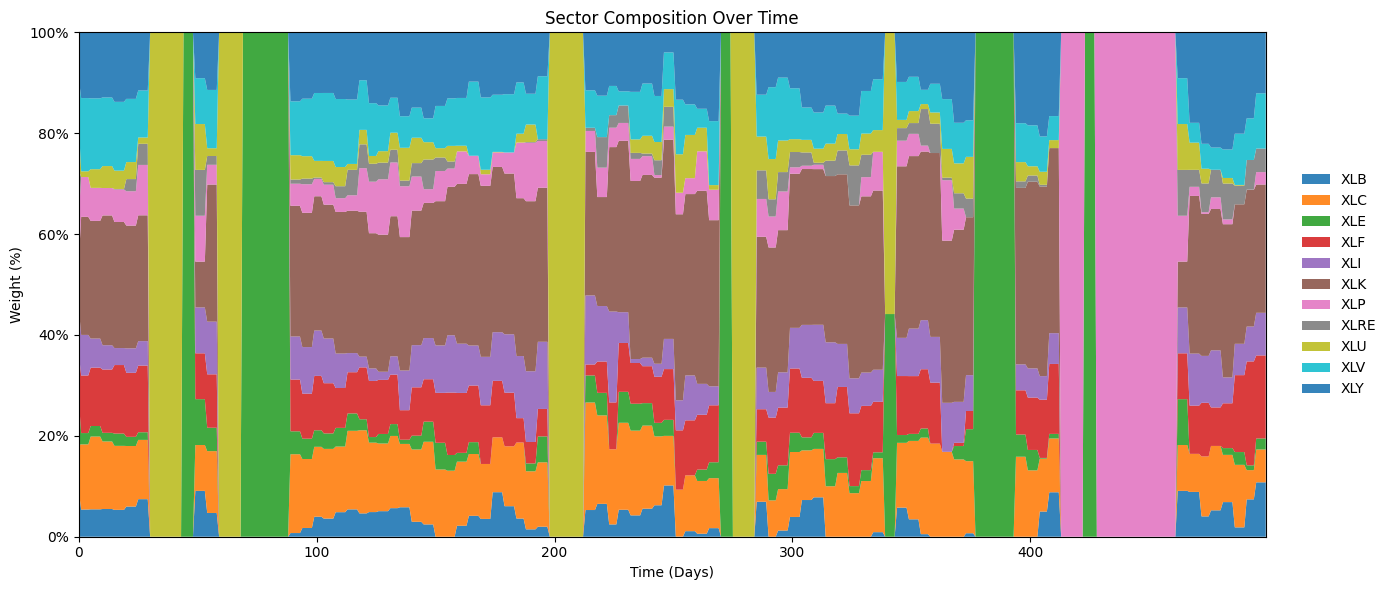

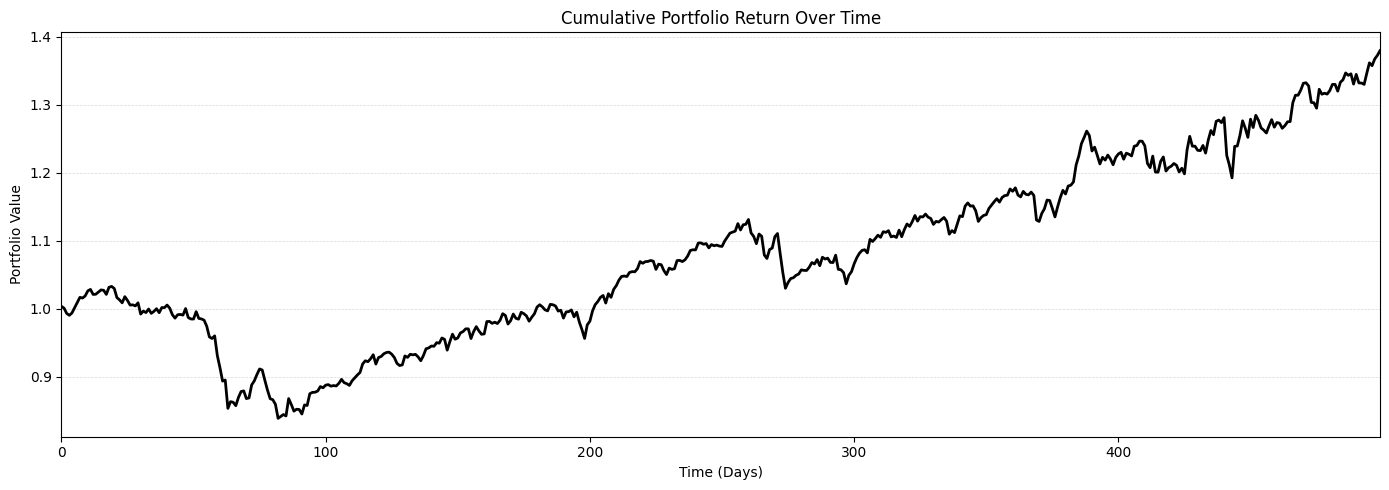

In [15]:
weights = test_result['weights_daily'].values

weights[0] = np.array([1.0 / len(ASSETS)] * len(ASSETS))

import sys
from pathlib import Path

from src.metrics import PortfolioMetrics
pm = PortfolioMetrics()

print(pm.summary(weights))
pm.plot_weights(weights)
pm.plot_cumulative_returns(weights)

In [16]:
np.save("MVO_CAPM_weights.npy", weights)

## Notes

- Optuna tunes on **3 walk-forward CV folds** (each ~1 fiscal year val window):
  - Fold 1: train `2015-07-01`–`2020-06-30` → val `2020-07-01`–`2021-06-30`
  - Fold 2: train `2015-07-01`–`2021-06-30` → val `2021-07-01`–`2022-06-30`
  - Fold 3: train `2015-07-01`–`2022-06-30` → val `2022-07-01`–`2023-06-30`
- The objective maximises the **mean net Sharpe** across all three val folds.
- Test begins at `2023-07-01` (after all val folds).
- Asset eligibility is dynamic: an asset is only used at a rebalance if it has a full lookback window.
- Costs use **asset-specific half-spread** on each weight change.
- Fallback is equal weight over eligible assets.
- The optimizer is fixed to **SLSQP**.
